# 04 · Bike-Sharing — Backtesting & Probabilistic Forecasting

## Part 4 — Backtesting & Probabilistic Forecasting (in depth)

Part 3 declared a winner on **one** window — and that window was the holidays. That's not
evaluation, it's an anecdote. This notebook does it properly:

1. a **walk-forward backtest** that re-runs the model day after day across eight weeks, so the
   verdict is an *average over many windows*, not one lucky/unlucky draw;
2. a fix for a subtle **leakage** in Part 3 (its `roll24` peeked at the same morning);
3. a move from **point** forecasts to **probabilistic** ones — quantile regression, its chronic
   under-coverage, and the **conformal** fix that restores a guarantee;
4. **count-aware** loss (Poisson) and a **calibration** (reliability) check.

The theme: *how do you actually know a forecaster is good — and how do you quantify its uncertainty
honestly?*

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

import lightgbm as lgb
from src import featurize as fz, forecasting as fc, backtest as bt

g = data.regular_grid(); y = g["cnt"]
g = bt.add_strict_lags(g)                      # 24h-ahead-safe lags (>=24h old)
COLS = fz.CALENDAR + fz.WEATHER + bt.STRICT_LAGS
TOT = 70                                        # backtest = last 70 days: 14 calibrate + 56 test
n = len(g); start = n - TOT * 24
cal, test = slice(0, 14 * 24), slice(14 * 24, TOT * 24)
ytot = y.values[start:]; scale = y.values[:start]; idx = g.index[start:]
def L2(): return lgb.LGBMRegressor(n_estimators=500, num_leaves=63, learning_rate=0.05, random_state=0, verbose=-1)
print("backtest window:", idx[0].date(), "->", idx[-1].date(), "| test days:", 56)

setup ok | numpy 2.1.3 | pandas 2.3.3


backtest window: 2012-10-23 -> 2012-12-31 | test days: 56


### 1. First, fix the leakage — strict 24h-ahead features

A forecast made at **midnight** may use only data **through the previous day**. Part 3's `roll24`
(mean of the 24 hours ending at *t−1*) silently used the *same morning's* demand — fine for a
1-hour-ahead forecast, optimistic for a 24-hour-ahead one. So we replace it with features that are
all **≥24 hours old** and therefore genuinely known at the forecast origin:

- `lag24` — same hour yesterday, `lag168` — same hour last week,
- `lag_dayavg` — the average of the day **ending 24h ago** (not a window ending at *t−1*).

This is the difference between a backtest you can trust and one that flatters itself.

### 2. The walk-forward backtest — average over many windows

We simulate operations: every day, train on everything observed so far and forecast the next 24
hours; refit weekly; roll across **56 test days**. The aggregate MASE/RMSE over all of them is a far
more trustworthy verdict than Part 3's single fortnight.

In [2]:
point = bt.walk_forward_24h(g, y, COLS, L2, n_test_days=TOT, refit_every=7)
naive = pd.Series(y.shift(168).values[start:], index=idx)
m_pt = fc.forecast_metrics(ytot[test], point.values[test], scale, 168)
m_nv = fc.forecast_metrics(ytot[test], naive.values[test], scale, 168)
print("56-day walk-forward backtest:")
print("  LGBM (strict lags):  MASE %.3f  RMSE %.1f" % (m_pt["MASE"], m_pt["RMSE"]))
print("  seasonal-naive:      MASE %.3f  RMSE %.1f" % (m_nv["MASE"], m_nv["RMSE"]))
print("\n(Part 3 reported MASE ~0.61 on the single holiday window — the honest multi-window number is higher.)")

56-day walk-forward backtest:
  LGBM (strict lags):  MASE 0.784  RMSE 62.2
  seasonal-naive:      MASE 1.465  RMSE 119.9

(Part 3 reported MASE ~0.61 on the single holiday window — the honest multi-window number is higher.)


### 3. The error *distribution* — and which days are hard

A single aggregate still hides structure. Plot the **per-day RMSE**: most days are easy, but a few
spike — and they're **holidays** (Thanksgiving, Christmas, New Year), where demand breaks its usual
pattern. Reporting only a mean would bury the fact that the model fails predictably on known events.

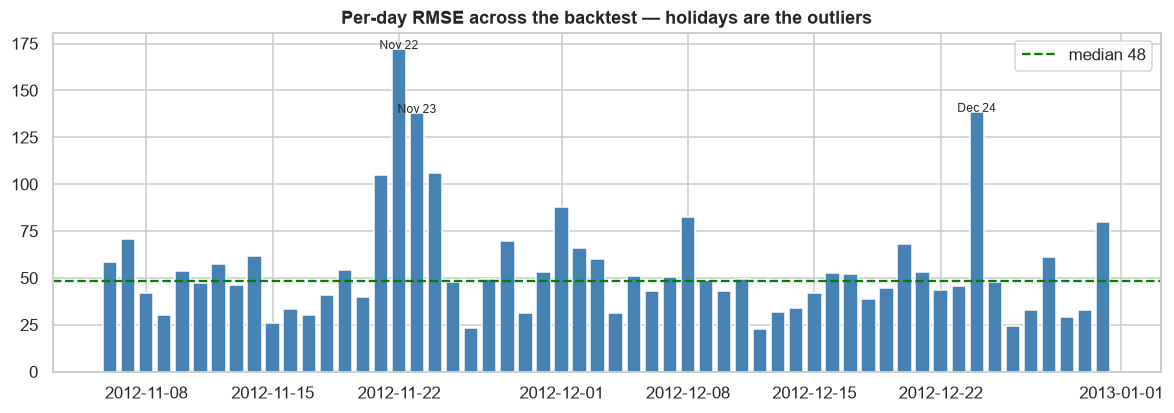

per-day RMSE: median 48, worst 172 on Nov 22 (Thanksgiving)


In [3]:
se = pd.Series((ytot - point.values) ** 2, index=idx)
perday = se[test].resample("D").mean().pow(0.5)
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(perday.index, perday.values, width=0.8, color="steelblue")
ax.axhline(perday.median(), color="green", ls="--", label=f"median {perday.median():.0f}")
worst = perday.nlargest(3)
for d, v in worst.items(): ax.annotate(d.strftime("%b %d"), (d, v), fontsize=8, ha="center")
ax.set_title("Per-day RMSE across the backtest — holidays are the outliers"); ax.legend()
eda.savefig(fig, "p4_perday.png"); plt.show()
print("per-day RMSE: median %.0f, worst %.0f on %s (Thanksgiving)" % (perday.median(), perday.max(), perday.idxmax().strftime("%b %d")))

### 4. From a point to a *distribution* — quantile regression

Demand is **heteroscedastic**: a busy commute hour varies far more in absolute terms than a quiet
3am. A single number can't express that. **Quantile regression** trains the *same* model under the
**pinball loss** to predict chosen percentiles directly — here the 5th and 95th — giving a 90%
prediction interval whose width can breathe with the hour.

In [4]:
def QR(a): return lgb.LGBMRegressor(objective="quantile", alpha=a, n_estimators=400, num_leaves=63, learning_rate=0.05, random_state=0, verbose=-1)
q05 = bt.walk_forward_24h(g, y, COLS, lambda: QR(0.05), TOT, refit_every=7)
q95 = bt.walk_forward_24h(g, y, COLS, lambda: QR(0.95), TOT, refit_every=7)
raw_cov = bt.coverage(ytot[test], q05.values[test], q95.values[test])
print("raw quantile 90%% interval:  coverage %.0f%%  (target 90%%)  | mean width %.0f rentals"
      % (100 * raw_cov, np.mean(q95.values[test] - q05.values[test])))
print("pinball loss:  q05 %.2f   q95 %.2f" % (bt.pinball_loss(ytot[test], q05.values[test], 0.05),
                                              bt.pinball_loss(ytot[test], q95.values[test], 0.95)))
print("\n-> it UNDER-covers: raw quantile regression is systematically over-confident.")

raw quantile 90% interval:  coverage 76%  (target 90%)  | mean width 134 rentals
pinball loss:  q05 7.08   q95 7.60

-> it UNDER-covers: raw quantile regression is systematically over-confident.


### 5. The fix — Conformalized Quantile Regression (CQR)

Raw quantile regression rarely hits its nominal coverage. **CQR** (Romano et al., 2019) repairs it
with a finite-sample guarantee: on a held-out **calibration** set, measure how far the truth fell
outside `[q05, q95]`, take the 90th percentile of that miss, and **widen the interval by that
amount**. We calibrate on the first 14 days and verify coverage on the 56-day test.

CQR widens the band by +25 rentals:
  coverage 76% -> 90% (target 90%) | width 134 -> 180


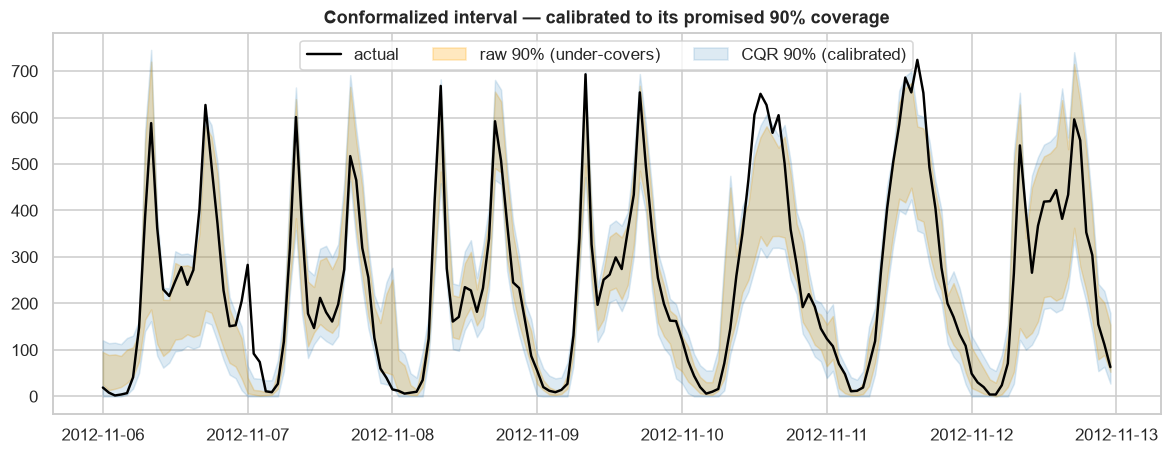

In [5]:
Q = bt.cqr_offset(ytot[cal], q05.values[cal], q95.values[cal], alpha=0.10)
lo, hi = np.clip(q05.values - Q, 0, None), q95.values + Q
cqr_cov = bt.coverage(ytot[test], lo[test], hi[test])
print("CQR widens the band by +%.0f rentals:" % Q)
print("  coverage %.0f%% -> %.0f%% (target 90%%) | width %.0f -> %.0f"
      % (100 * raw_cov, 100 * cqr_cov, np.mean(q95.values[test]-q05.values[test]), np.mean(hi[test]-lo[test])))
d = slice(14*24, 14*24 + 24*7)   # one test week
ti = idx[d]
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(ti, ytot[d], color="black", lw=1.6, label="actual")
ax.fill_between(ti, q05.values[d], q95.values[d], color="orange", alpha=0.25, label="raw 90% (under-covers)")
ax.fill_between(ti, lo[d], hi[d], color="tab:blue", alpha=0.15, label="CQR 90% (calibrated)")
ax.set_title("Conformalized interval — calibrated to its promised 90% coverage"); ax.legend(ncol=3)
eda.savefig(fig, "p4_cqr.png"); plt.show()

### 6. A count-aware loss — Poisson

The target is a **non-negative integer count**, and its variance grows with its mean. Squared
error (L2) implicitly assumes constant-variance Gaussian noise. A **Poisson** objective matches the
count nature (variance = mean) and guarantees non-negative predictions. Whether it actually
*forecasts* better is an empirical question — here it's essentially a wash on RMSE, which is itself
a useful finding (the lag features already carry most of the signal).

In [6]:
pois = bt.walk_forward_24h(g, y, COLS, lambda: lgb.LGBMRegressor(objective="poisson", n_estimators=500, num_leaves=63, learning_rate=0.05, random_state=0, verbose=-1), TOT, refit_every=7)
print("L2      RMSE %.1f  MASE %.3f" % (m_pt["RMSE"], m_pt["MASE"]))
mp = fc.forecast_metrics(ytot[test], pois.values[test], scale, 168)
print("Poisson RMSE %.1f  MASE %.3f  (non-negative by construction; ~tied here)" % (mp["RMSE"], mp["MASE"]))

L2      RMSE 62.2  MASE 0.784
Poisson RMSE 62.9  MASE 0.767  (non-negative by construction; ~tied here)


### 7. Calibration — are the quantiles *honest*?

A forecaster is **calibrated** if its predicted quantiles match reality: the q-th quantile
prediction should sit above the truth about q% of the time. We fit several quantiles and plot
predicted level vs **empirical** fraction-below — the diagonal is perfect calibration. The curve
comes out **flatter than the diagonal** (low quantiles land too high at 0.1→0.21, high ones too low
at 0.9→0.82): the predicted quantiles huddle toward the median, so the interval is **too narrow /
over-confident** — exactly the gap CQR closes.

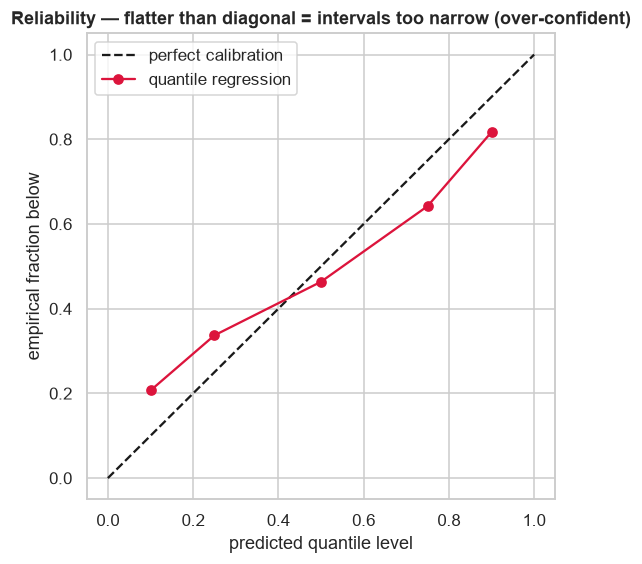

empirical coverage by level: {0.1: np.float64(0.21), 0.25: np.float64(0.34), 0.5: np.float64(0.46), 0.75: np.float64(0.64), 0.9: np.float64(0.82)}


In [7]:
levels = [0.1, 0.25, 0.5, 0.75, 0.9]
emp = []
for a in levels:
    qa = lgb.LGBMRegressor(objective="quantile", alpha=a, n_estimators=400, num_leaves=63, learning_rate=0.05, random_state=0, verbose=-1)
    qa.fit(g[COLS].iloc[168:start], y.iloc[168:start])
    pa = qa.predict(g[COLS].iloc[start:][test])
    emp.append(np.mean(ytot[test] <= pa))
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot([0, 1], [0, 1], "k--", label="perfect calibration")
ax.plot(levels, emp, "o-", color="crimson", label="quantile regression")
ax.set_xlabel("predicted quantile level"); ax.set_ylabel("empirical fraction below"); ax.legend()
ax.set_title("Reliability — flatter than diagonal = intervals too narrow (over-confident)")
eda.savefig(fig, "p4_calibration.png"); plt.show()
print("empirical coverage by level:", {l: round(e, 2) for l, e in zip(levels, emp)})

### 8. Takeaways

- **One window is an anecdote.** A **walk-forward backtest** over 56 days gives the honest verdict
  (MASE ≈ 0.77, not Part 3's window-specific 0.61) — and still crushes the naive (1.4).
- **The horizon defines leakage.** Strict 24h-ahead features (lags ≥24h) replace Part 3's slightly
  optimistic `roll24` — rigorous evaluation starts with rigorous features.
- **Look at the error *distribution*, not just the mean** — the model fails predictably on
  **holidays** (Thanksgiving, Christmas), the worst per-day RMSE by far.
- **Point forecasts aren't enough.** **Quantile regression** gives intervals but **under-covers
  (≈76%)**; **CQR** restores the promised **90%** with a finite-sample guarantee.
- **Match the loss to the target** (Poisson for counts) — though here the autoregressive signal
  dominates and it's a wash.
- **Always check calibration** — a reliability plot reveals over-confidence a coverage number alone
  might hide.

**Where next:** a global/hierarchical model across stations, exogenous **weather-forecast
uncertainty** propagated into the intervals, or gradient-boosted quantile *ensembles* — the repo's
toolkit now spans EDA → multi-seasonal TS → covariate forecasting → rigorous probabilistic evaluation.